### Explorative Analyse der Smartmeter Daten

In [1]:
import sys
import os
import polars as pl
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
sys.path.append(os.path.abspath("../03_src"))

from data_loader import processed_data_load
path_to_file = "../02_data/processed/combined_data_cleaned.parquet"
df_cleaned = processed_data_load(path_to_file)
df_cleaned

✅ Processed Data geladen: 937456 Zeilen, 140 Spalten.


timestamp,timestamp_local,date,year_str,household_id,group_assignment,affects_timepoint,kwh_received_total,kwh_received_heatpump,kwh_received_other,kwh_returned_total,group,weather_id,installation_haspvsystem,protocols_available,protocols_hasmultiplevisits,protocols_reportids,metadata_available,smartmeterdata_available_15min,smartmeterdata_available_daily,smartmeterdata_available_monthly,temperature_avg_daily,temperature_max_daily,temperature_min_daily,heatingdegree_sia_daily,heatingdegree_us_daily,coolingdegree_us_daily,humidity_avg_daily,precipitation_total_daily,sunshine_duration_daily,timestamp_local_right,report_id,household_id_right,visit_year,visit_date,building_type,building_housingunits,…,heatpump_groundsource_currentpressure,heatpump_groundsource_currentpressure_okay,heatpump_groundsource_currenttemperature,heatpump_groundsource_currenttemperature_okay,heatpump_heatingcurvesetting_toohigh_beforevisit,heatpump_heatingcurvesetting_changed,heatpump_heatingcurvesetting_outside20_beforevisit,heatpump_heatingcurvesetting_outside0_beforevisit,heatpump_heatingcurvesetting_outsideminus8_beforevisit,heatpump_heatingcurvesetting_outside20_aftervisit,heatpump_heatingcurvesetting_outside0_aftervisit,heatpump_heatingcurvesetting_outsideminus8_aftervisit,heatpump_heatinglimitsetting_toohigh_beforevisit,heatpump_heatinglimitsetting_changed,heatpump_heatinglimitsetting_beforevisit,heatpump_heatinglimitsetting_aftervisit,heatpump_nightsetbacksetting_activated_beforevisit,heatpump_nightsetbacksetting_activated_aftervisit,dhw_temperaturesetting_categorization,dhw_temperaturesetting_changed,dhw_temperaturesetting_beforevisit,dhw_temperaturesetting_aftervisit,dhw_storage_lastdescaling_toolongago,dhw_storage_lastdescaling_year,heatdistribution_expansiontank_pressure_categorization,heatdistribution_expansiontank_pressure_actual,heatdistribution_expansiontank_pressure_target,heatdistribution_expansiontank_systemheight,heatdistribution_circulation_pumpstageposition_changed,heatdistribution_circulation_pumpstageposition_beforevisit,heatdistribution_circulation_pumpstageposition_aftervisit,heatdistribution_recommendation_insulatepipes,heatdistribution_recommendation_installthermostaticvalve,heatdistribution_recommendation_installrpmvalve,visit_date_date,year_str_right,swissix_base
"datetime[μs, UTC]","datetime[μs, Europe/Zurich]",date,str,str,str,str,f64,f64,f64,f64,str,str,bool,bool,bool,str,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,"datetime[μs, Europe/Zurich]",i64,i64,i64,date,str,f64,…,f64,bool,f64,bool,bool,bool,f64,f64,f64,f64,f64,f64,bool,bool,i64,i64,bool,bool,str,bool,f64,i64,bool,i64,str,f64,f64,f64,bool,i64,i64,bool,bool,bool,date,str,f64
2019-03-02 23:59:59 UTC,2019-03-03 00:59:59 CET,2019-03-03,"""2019""","""100101""","""control""","""unknown""",18.33,null,null,8.64,"""control""","""z6I""",true,false,false,null,true,true,true,true,8.4,13.8,2.9,11.6,9.9,0.0,65.9,0.0,6.3,2019-03-03 00:00:00 CET,null,null,null,null,"""unknown""",null,…,null,false,null,false,false,false,null,null,null,null,null,null,false,false,null,null,false,false,"""Unbekannt""",false,null,null,false,null,"""Unbekannt""",null,null,null,false,null,null,false,false,false,null,null,22.79
2019-03-03 23:59:59 UTC,2019-03-04 00:59:59 CET,2019-03-04,"""2019""","""100101""","""control""","""unknown""",15.03,null,null,9.04,"""control""","""z6I""",true,false,false,null,true,true,true,true,7.8,13.8,5.0,12.2,10.5,0.0,54.2,2.6,1.3,2019-03-04 00:00:00 CET,null,null,null,null,"""unknown""",null,…,null,false,null,false,false,false,null,null,null,null,null,null,false,false,null,null,false,false,"""Unbekannt""",false,null,null,false,null,"""Unbekannt""",null,null,null,false,null,null,false,false,false,null,null,37.938333
2019-03-04 23:59:59 UTC,2019-03-05 00:59:59 CET,2019-03-05,"""2019""","""100101""","""control""","""unknown""",16.69,null,null,4.57,"""control""","""z6I""",true,false,false,null,true,true,true,true,7.4,11.9,2.7,12.6,10.9,0.0,55.5,0.2,7.7,2019-03-05 00:0

In [2]:
daily_normalized = (
    df_cleaned.group_by(pl.col("date")).agg([
        (pl.col("kwh_received_heatpump").sum() / pl.col("household_id").n_unique()).alias("avg_hp_per_h"),
        (pl.col("kwh_received_total").sum() / pl.col("household_id").n_unique()).alias("avg_total_per_h"),
        (pl.col("kwh_returned_total").sum() / pl.col("household_id").n_unique()).alias("avg_total_returned_per_h"),
        pl.col("temperature_avg_daily").mean().alias("avg_temp"),
        pl.col("swissix_base").mean().alias("avg_swissix_base")
    ])
    .drop_nulls()
    .sort("date")
)
daily_normalized

date,avg_hp_per_h,avg_total_per_h,avg_total_returned_per_h,avg_temp,avg_swissix_base
date,f64,f64,f64,f64,f64
2018-11-03,2.149669,32.66596,0.000265,4.106579,62.62
2018-11-04,2.013576,32.031192,0.000596,4.106579,51.558333
2018-11-05,1.97053,33.715762,0.000331,4.106579,65.679167
2018-11-06,2.126026,32.822649,0.000596,4.106579,57.92125
2018-11-07,2.035695,32.103179,0.000199,4.106579,58.779167
…,…,…,…,…,…
2024-03-17,0.121599,25.603894,5.251082,7.410457,60.337917
2024-03-18,0.121095,27.510469,2.356029,7.410469,81.739583
2024-03-19,0.117889,27.488179,0.827696,7.410977,84.41875


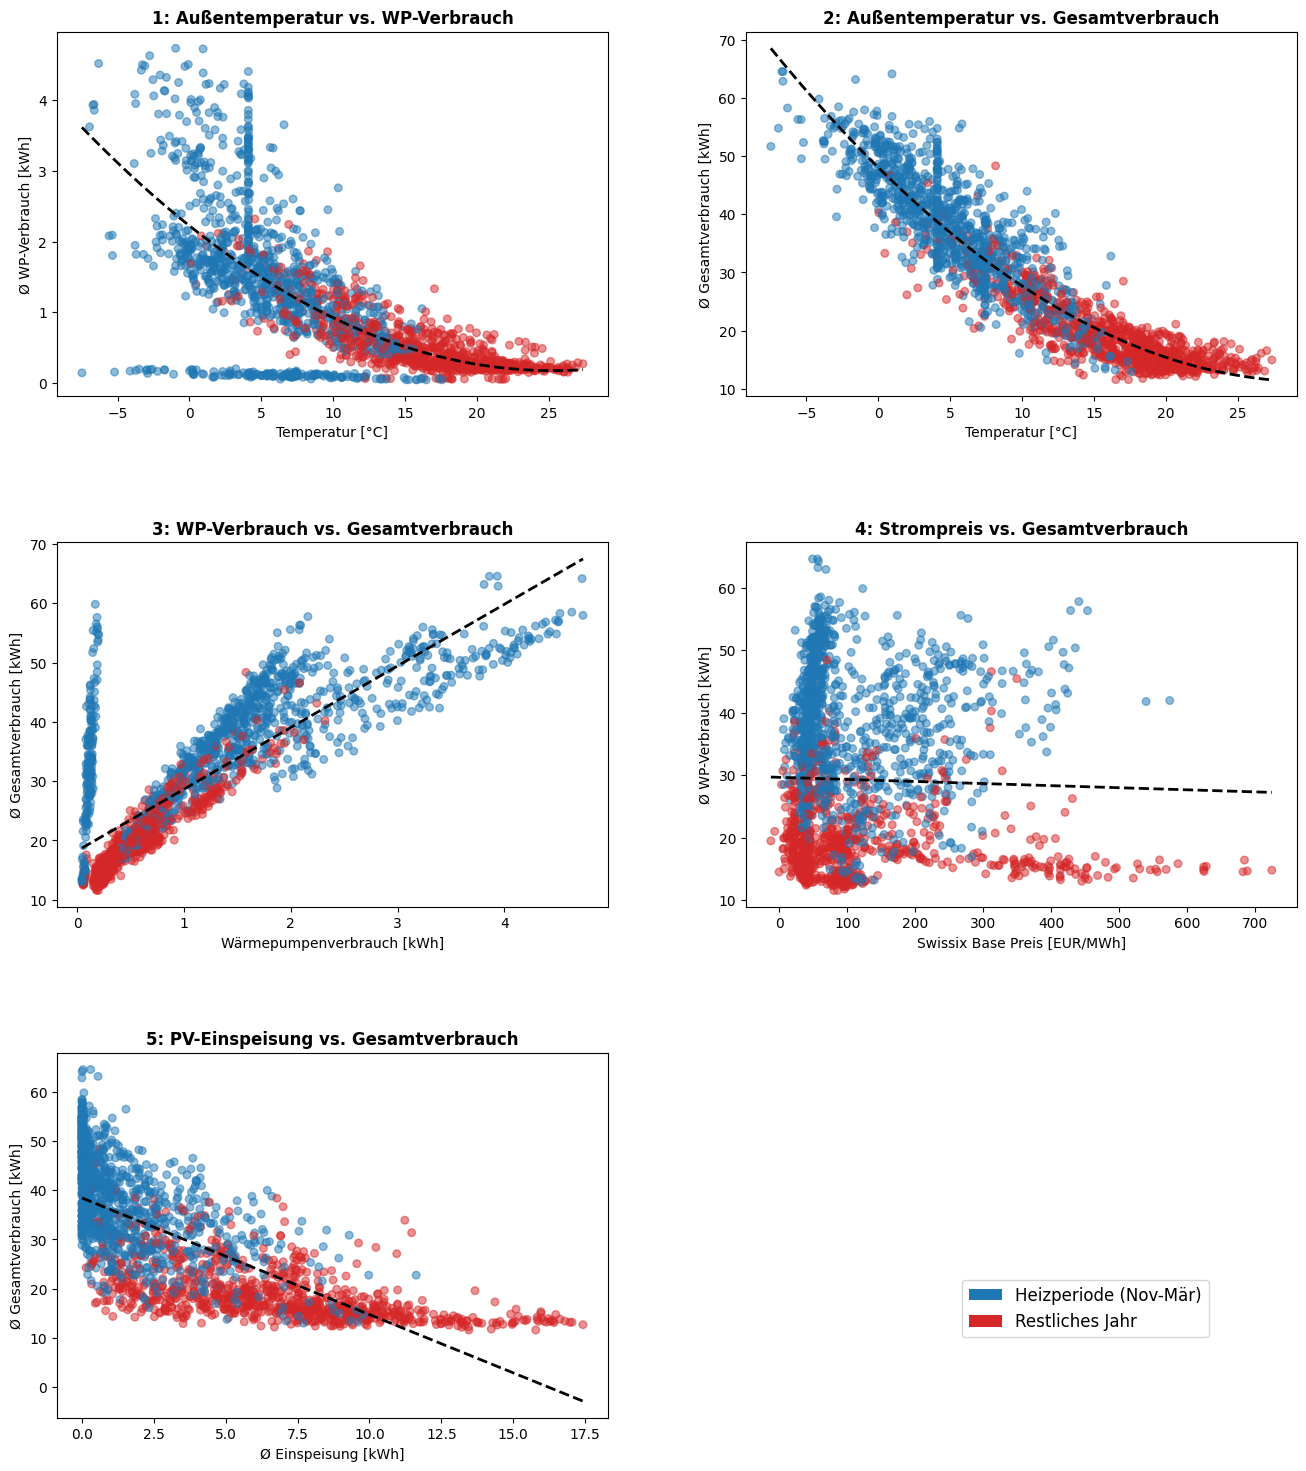

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

df_plot = daily_normalized.with_columns(
    pl.col("date").dt.month().alias("month")
).drop_nulls()

colors = ['#1f77b4' if m in [10, 11, 12, 1, 2, 3] else '#d62728' for m in df_plot["month"]]

def add_trendline(ax, x, y, degree=1, color="black"):
    z = np.polyfit(x, y, degree)
    p = np.poly1d(z)
    r_sq = np.corrcoef(x, y)[0, 1]**2
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, p(x_range), color=color, linestyle="--", linewidth=2, 
            label=f"Trend (R²={r_sq:.2f})")

# Layout 3x2
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# --- PLOT 1: Die Heizkurve (WP) ---
ax = axes[0, 0]
ax.scatter(df_plot["avg_temp"], df_plot["avg_hp_per_h"], c=colors, alpha=0.5, s=30)
add_trendline(ax, df_plot["avg_temp"], df_plot["avg_hp_per_h"], degree=2) 
ax.set_title("1: Außentemperatur vs. WP-Verbrauch", fontweight='bold')
ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Ø WP-Verbrauch [kWh]")

# --- PLOT 2: Temperatur vs. Gesamtverbrauch ---
ax = axes[0, 1]
ax.scatter(df_plot["avg_temp"], df_plot["avg_total_per_h"], c=colors, alpha=0.5, s=30)
add_trendline(ax, df_plot["avg_temp"], df_plot["avg_total_per_h"], degree=2)
ax.set_title("2: Außentemperatur vs. Gesamtverbrauch", fontweight='bold')
ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Ø Gesamtverbrauch [kWh]")

# --- PLOT 3: Kopplung WP & Haus ---
ax = axes[1, 0]
ax.scatter(df_plot["avg_hp_per_h"], df_plot["avg_total_per_h"], c=colors, alpha=0.5, s=30)
add_trendline(ax, df_plot["avg_hp_per_h"], df_plot["avg_total_per_h"])
ax.set_title("3: WP-Verbrauch vs. Gesamtverbrauch", fontweight='bold')
ax.set_xlabel("Wärmepumpenverbrauch [kWh]")
ax.set_ylabel("Ø Gesamtverbrauch [kWh]")

# --- PLOT 4: Marktdynamik ---
ax = axes[1, 1]
ax.scatter(df_plot["avg_swissix_base"], df_plot["avg_total_per_h"], c=colors, alpha=0.5, s=30)
add_trendline(ax, df_plot["avg_swissix_base"], df_plot["avg_total_per_h"])
ax.set_title("4: Strompreis vs. Gesamtverbrauch", fontweight='bold')
ax.set_xlabel("Swissix Base Preis [EUR/MWh]")
ax.set_ylabel("Ø WP-Verbrauch [kWh]")

# --- PLOT 5: PV-Effekt ---
ax = axes[2, 0]
ax.scatter(df_plot["avg_total_returned_per_h"], df_plot["avg_total_per_h"], c=colors, alpha=0.5, s=30)
add_trendline(ax, df_plot["avg_total_returned_per_h"], df_plot["avg_total_per_h"])
ax.set_title("5: PV-Einspeisung vs. Gesamtverbrauch", fontweight='bold')
ax.set_xlabel("Ø Einspeisung [kWh]")
ax.set_ylabel("Ø Gesamtverbrauch [kWh]")

# Plot 6 leer lassen
axes[2, 1].axis('off')

# Manuelle Legende für die Farben
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Heizperiode (Nov-Mär)'),
                   Patch(facecolor='#d62728', label='Restliches Jahr')]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.85, 0.15), fontsize=12)

plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()

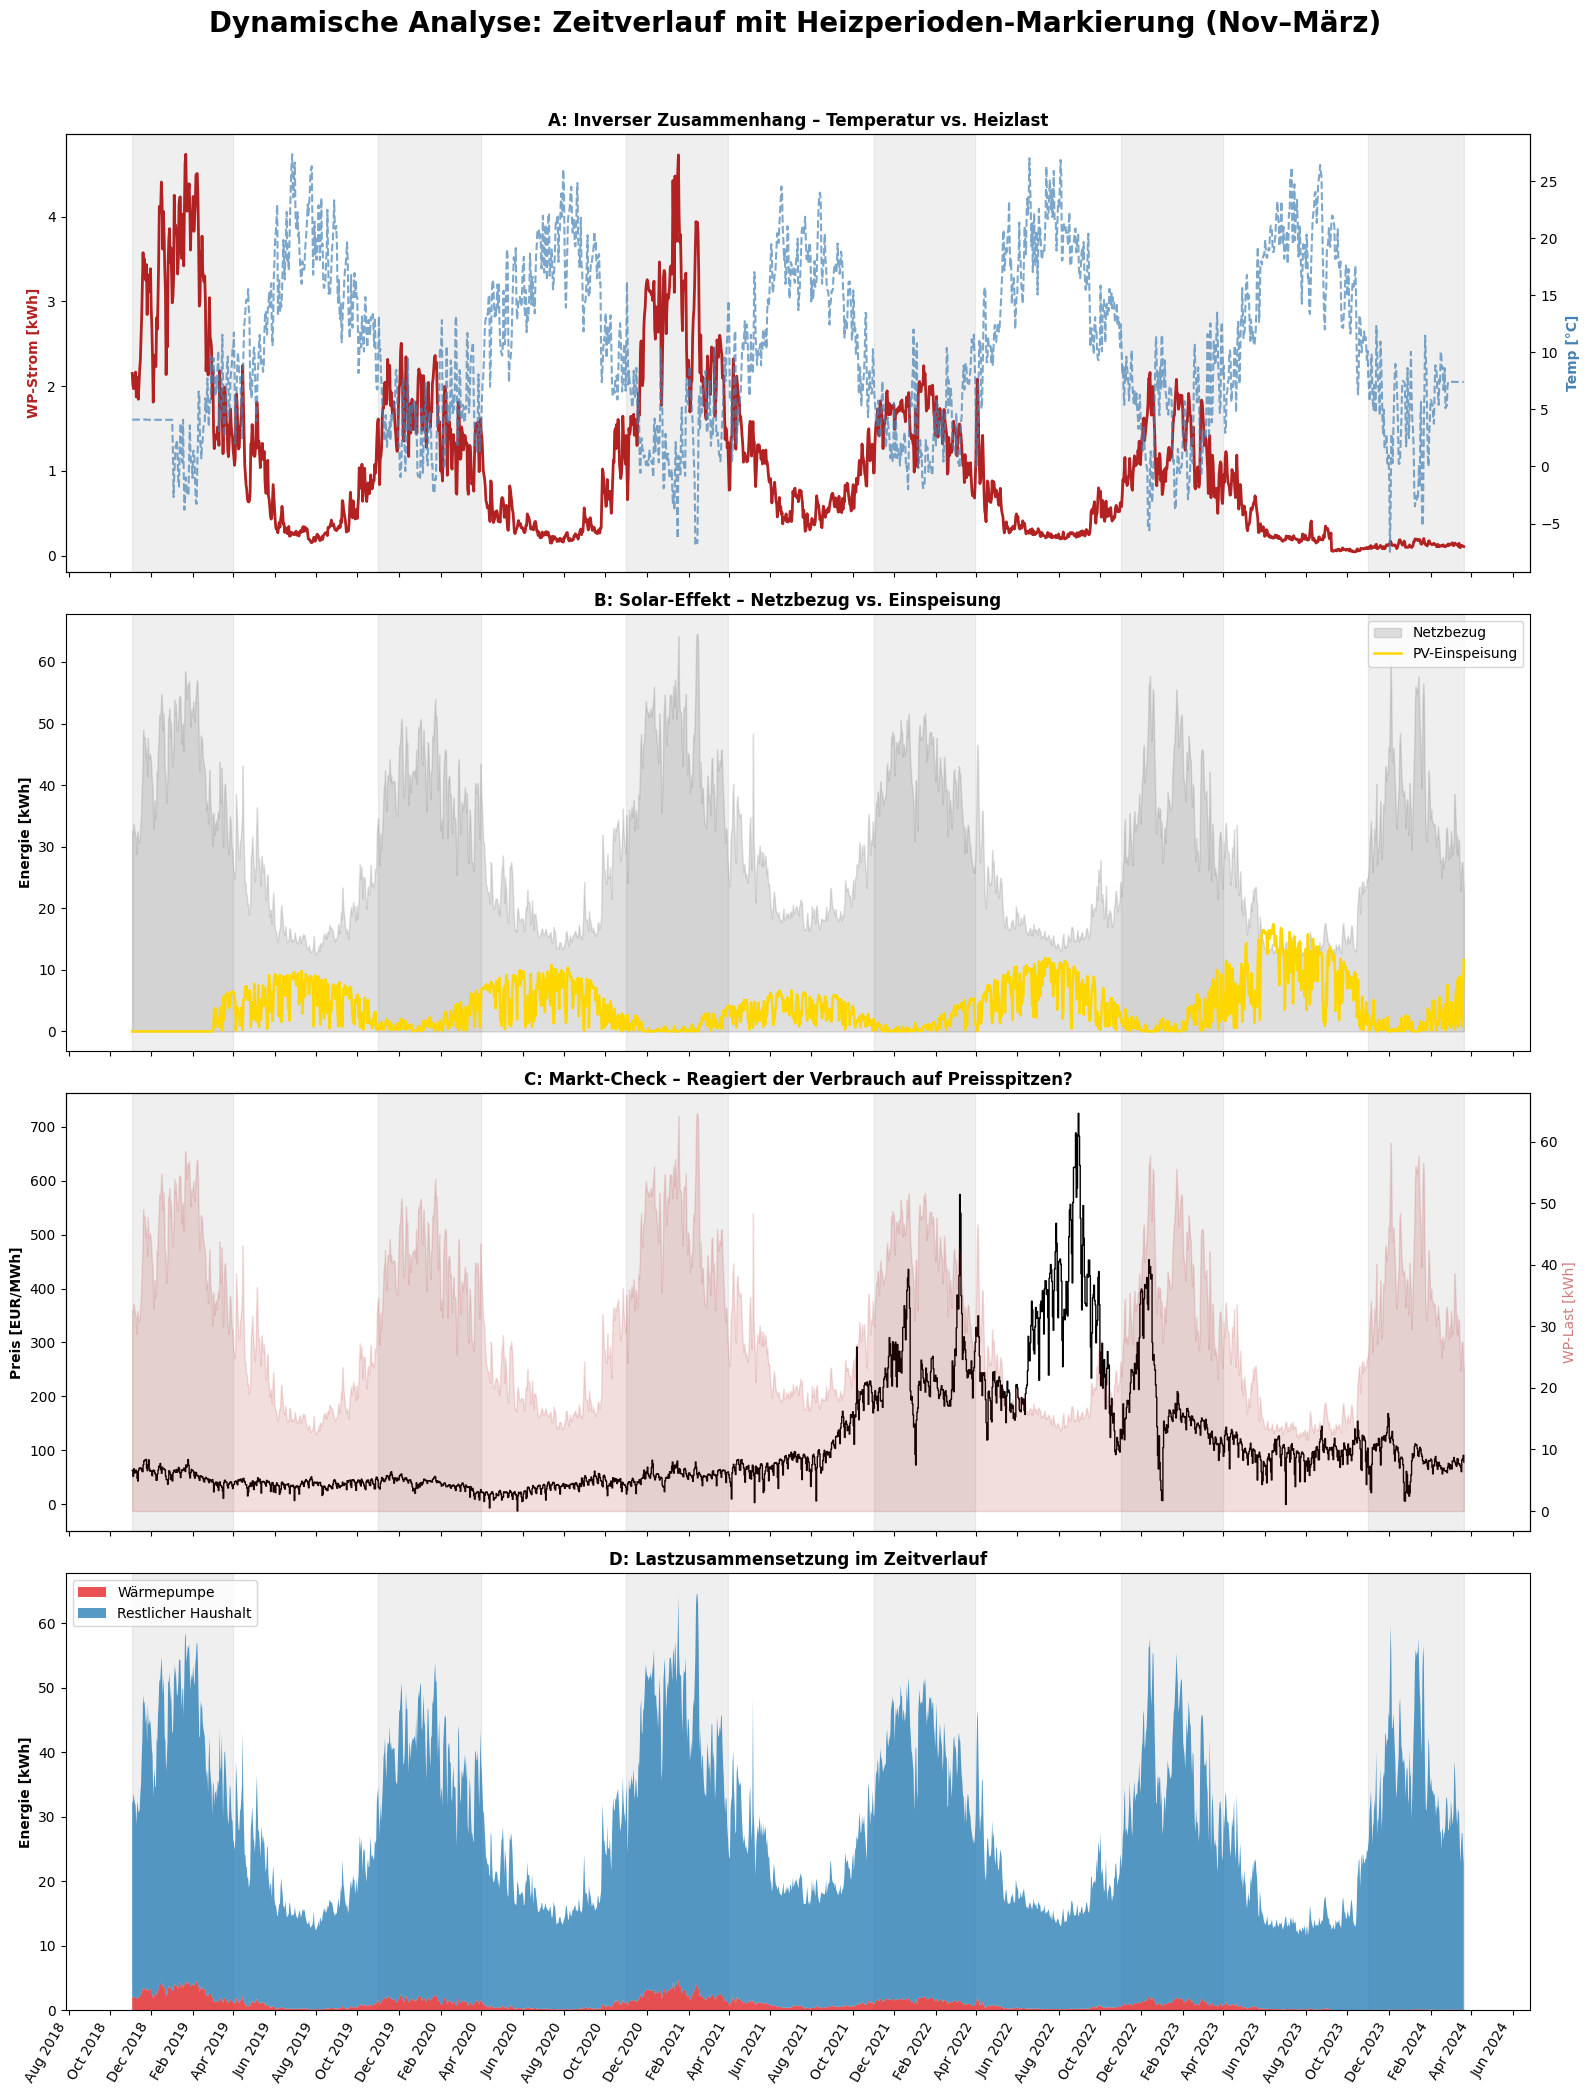

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import polars as pl

# -------------------------------------------------
# 1. Daten vorbereiten
# -------------------------------------------------
df_line = daily_normalized.sort("date")
min_date = df_line["date"].min()
max_date = df_line["date"].max()
years = df_line["date"].dt.year().unique().to_list()

# Falls Restlast noch nicht existiert
if "rest_load" not in df_line.columns:
    df_line = df_line.with_columns(
        (pl.col("avg_total_per_h") - pl.col("avg_hp_per_h")).alias("rest_load")
    )

# -------------------------------------------------
# 2. Figure & Layout
# -------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 22), sharex=True)
fig.suptitle(
    "Dynamische Analyse: Zeitverlauf mit Heizperioden-Markierung (Nov–März)",
    fontsize=20,
    fontweight="bold"
)

# -------------------------------------------------
# 3. Heizperioden-Markierung
# -------------------------------------------------
def add_heating_seasons(ax):
    for year in [years[0] - 1] + years:
        start_winter = datetime(year, 11, 1).date()
        end_winter = datetime(year + 1, 3, 31).date()

        if end_winter >= min_date and start_winter <= max_date:
            ax.axvspan(
                max(start_winter, min_date),
                min(end_winter, max_date),
                color="gray",
                alpha=0.12,
                zorder=0
            )

# -------------------------------------------------
# PLOT A – Thermische Kopplung
# -------------------------------------------------
ax1 = axes[0]
add_heating_seasons(ax1)
ax1_tw = ax1.twinx()

ax1.plot(
    df_line["date"],
    df_line["avg_hp_per_h"],
    color="firebrick",
    linewidth=2,
    label="Ø WP-Verbrauch"
)

ax1_tw.plot(
    df_line["date"],
    df_line["avg_temp"],
    color="steelblue",
    linestyle="--",
    alpha=0.7,
    label="Außentemperatur"
)

ax1.set_ylabel("WP-Strom [kWh]", color="firebrick", fontweight="bold")
ax1_tw.set_ylabel("Temp [°C]", color="steelblue", fontweight="bold")
ax1.set_title("A: Inverser Zusammenhang – Temperatur vs. Heizlast", fontweight="bold")

# -------------------------------------------------
# PLOT B – PV-Interaktion
# -------------------------------------------------
ax2 = axes[1]
add_heating_seasons(ax2)

ax2.fill_between(
    df_line["date"],
    df_line["avg_total_per_h"],
    color="gray",
    alpha=0.25,
    label="Netzbezug"
)

ax2.plot(
    df_line["date"],
    df_line["avg_total_returned_per_h"],
    color="gold",
    linewidth=1.8,
    label="PV-Einspeisung"
)

ax2.set_ylabel("Energie [kWh]", fontweight="bold")
ax2.set_title("B: Solar-Effekt – Netzbezug vs. Einspeisung", fontweight="bold")
ax2.legend(loc="upper right")

# -------------------------------------------------
# PLOT C – Markt-Dynamik
# -------------------------------------------------
ax3 = axes[2]
add_heating_seasons(ax3)
ax3_tw = ax3.twinx()

ax3.step(
    df_line["date"],
    df_line["avg_swissix_base"],
    where="post",
    color="black",
    linewidth=1,
    label="Swissix-Preis"
)

ax3_tw.fill_between(
    df_line["date"],
    df_line["avg_total_per_h"],
    color="firebrick",
    alpha=0.15
)

ax3.set_ylabel("Preis [EUR/MWh]", fontweight="bold")
ax3_tw.set_ylabel("WP-Last [kWh]", color="firebrick", alpha=0.6)
ax3.set_title("C: Markt-Check – Reagiert der Verbrauch auf Preisspitzen?", fontweight="bold")

# -------------------------------------------------
# PLOT D – Lastzusammensetzung
# -------------------------------------------------
ax4 = axes[3]
add_heating_seasons(ax4)

ax4.stackplot(
    df_line["date"],
    df_line["avg_hp_per_h"],
    df_line["rest_load"],
    labels=["Wärmepumpe", "Restlicher Haushalt"],
    colors=["#e31a1c", "#1f78b4"],
    alpha=0.75
)

ax4.set_ylabel("Energie [kWh]", fontweight="bold")
ax4.set_title("D: Lastzusammensetzung im Zeitverlauf", fontweight="bold")
ax4.legend(loc="upper left")

# -------------------------------------------------
# 4. X-Achsen-Optimierung (WICHTIG)
# -------------------------------------------------

# Nur jeder 2. Monat
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Minor-Ticks entfernen (macht es sonst unlesbar)

# Nur unterster Plot zeigt Labels
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# Rotation & Schriftgröße
plt.setp(ax4.get_xticklabels(), rotation=60, ha="right")
# Layout optimieren
fig.subplots_adjust(bottom=0.08)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

plt.show()

C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,


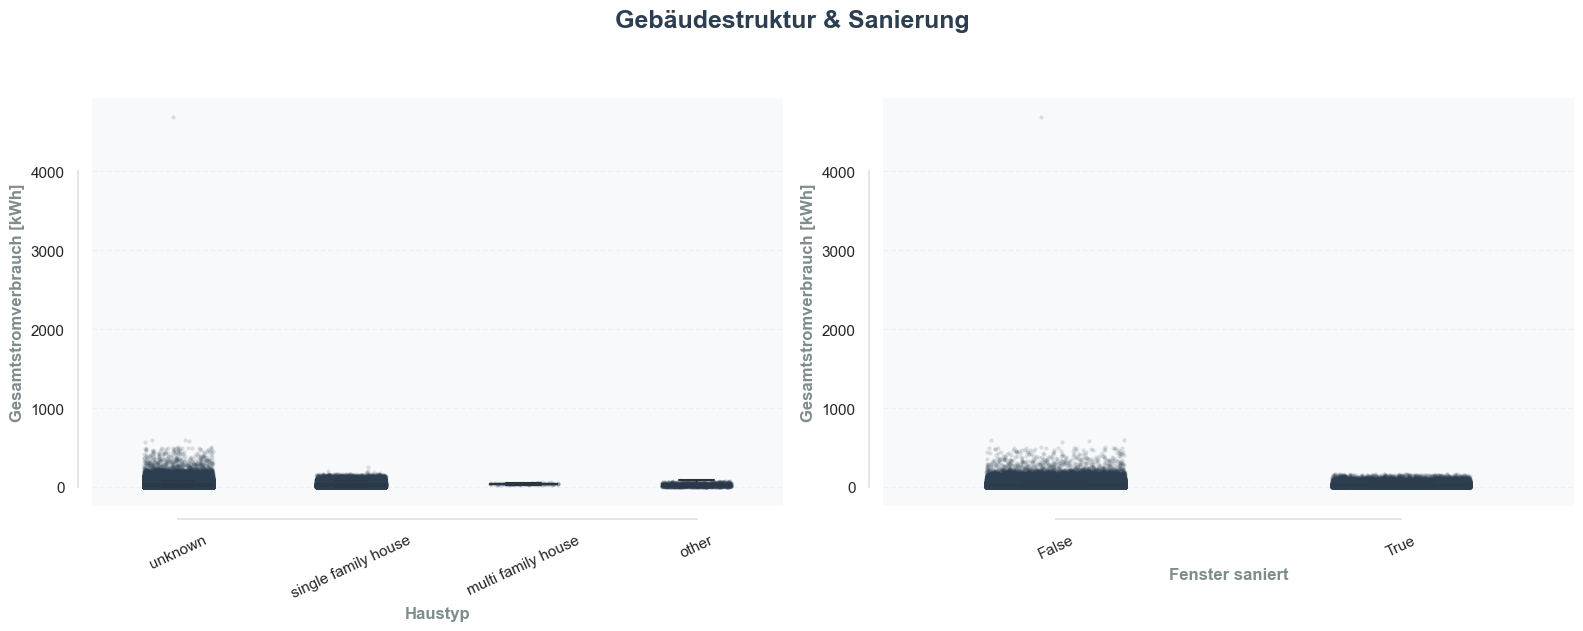

C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,


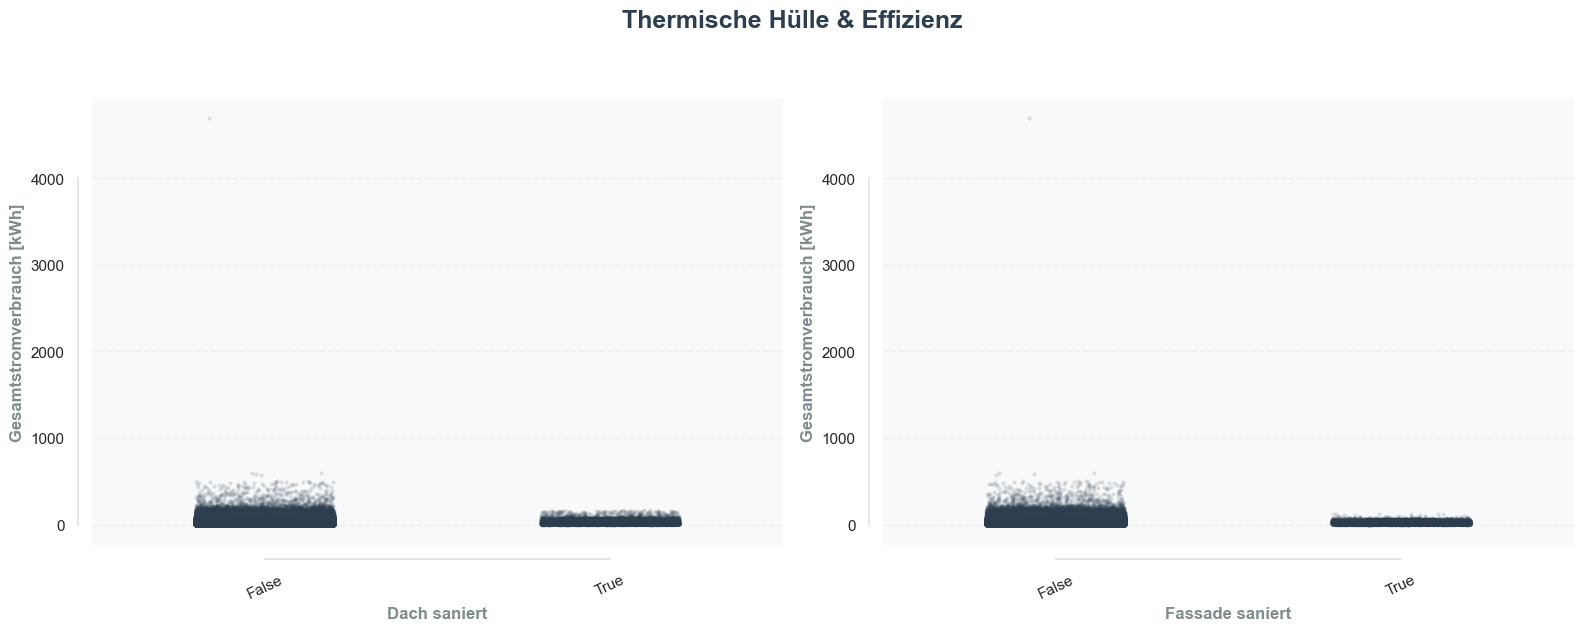

C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,


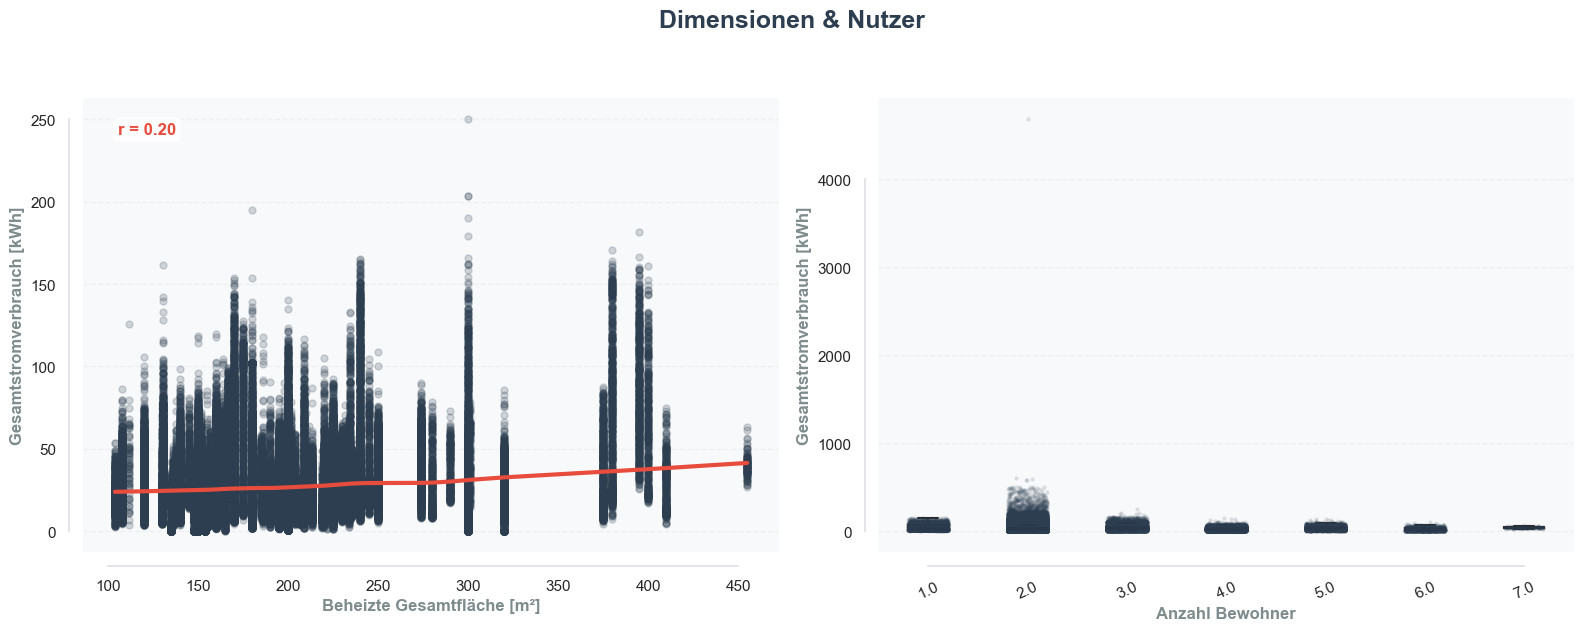

C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20680\476751707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax,


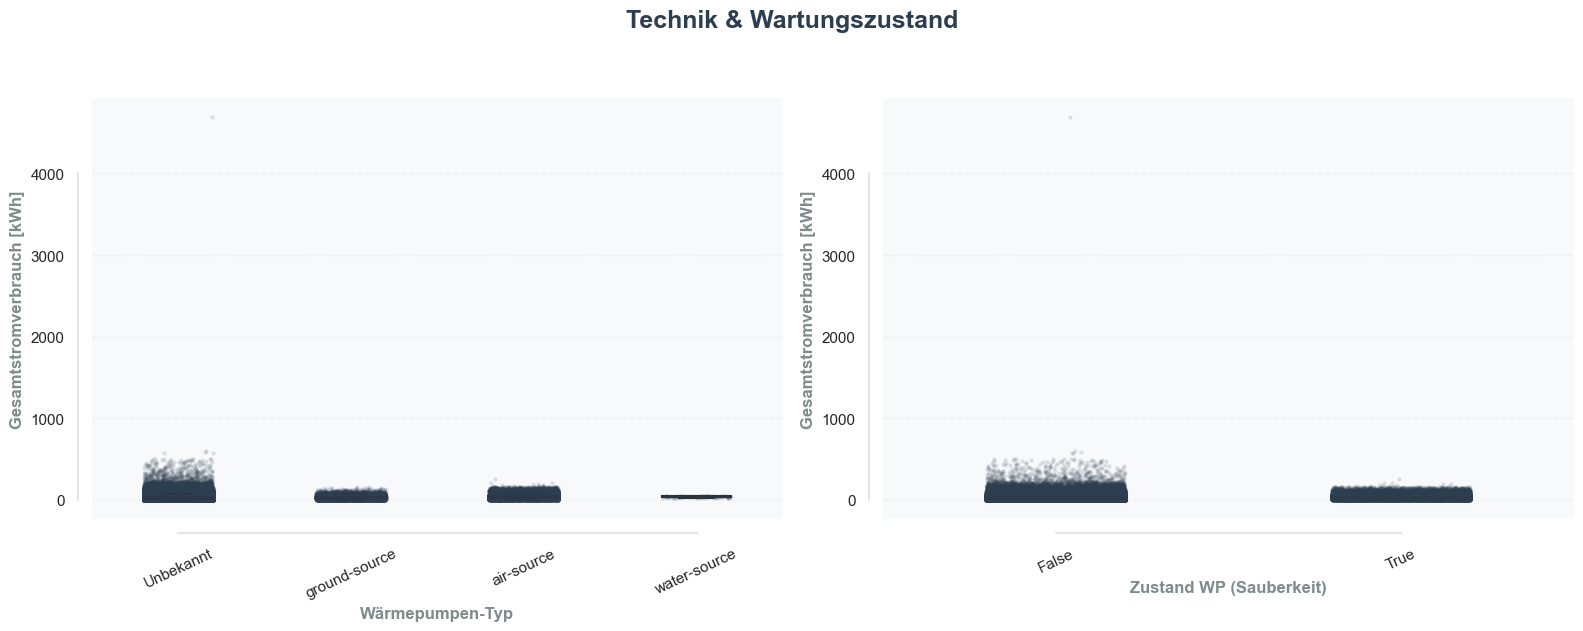

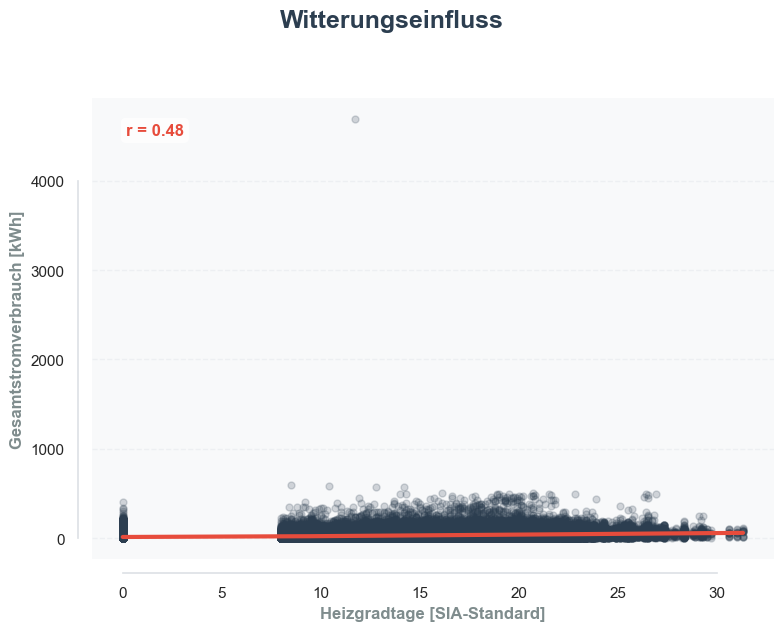

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_bivariate_plots(df):
    # --- GLOBALESTYLING ---
    # Wir setzen ein modernes Dark-Grid oder White-Grid mit spezifischen Farben
    sns.set_theme(style="white", rc={
        "axes.facecolor": "#f8f9fa", 
        "figure.facecolor": "white",
        "axes.edgecolor": "#dee2e6",
        "grid.color": "#e9ecef"
    })
    
    target_var = "kwh_received_total"
    
    # Hochwertige Farbpaletten
    scatter_color = "#2c3e50"  # Midnight Blue
    line_color = "#e74c3c"     # Soft Red
    box_palette = ["#95a5a6", "#3498db"] # Grau für Nein, Blau für Ja
    
    label_map = {
        "building_type": "Haustyp",
        "building_renovated_windows": "Fenster saniert",
        "building_renovated_roof": "Dach saniert",
        "building_renovated_walls": "Fassade saniert",
        "building_floorareaheated_total": "Beheizte Gesamtfläche [m²]",
        "kwh_received_total": "Gesamtstromverbrauch [kWh]",
        "building_residents": "Anzahl Bewohner",
        "heatpump_installation_type": "Wärmepumpen-Typ",
        "heatpump_clean": "Zustand WP (Sauberkeit)",
        "heatingdegree_sia_daily": "Heizgradtage [SIA-Standard]"
    }

    analysis_groups = [
        {"title": "Gebäudestruktur & Sanierung", 
         "pairs": [("building_type", target_var, "box"), 
                   ("building_renovated_windows", target_var, "box")]},
        
        {"title": "Thermische Hülle & Effizienz", 
         "pairs": [("building_renovated_roof", target_var, "box"), 
                   ("building_renovated_walls", target_var, "box")]},

        {"title": "Dimensionen & Nutzer", 
         "pairs": [("building_floorareaheated_total", target_var, "scatter"), 
                   ("building_residents", target_var, "box")]},
        
        {"title": "Technik & Wartungszustand", 
         "pairs": [("heatpump_installation_type", target_var, "box"), 
                   ("heatpump_clean", target_var, "box")]},
        
        {"title": "Witterungseinfluss", 
         "pairs": [("heatingdegree_sia_daily", target_var, "scatter")]}
    ]

    for group in analysis_groups:
        num_plots = len(group["pairs"])
        fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 6), squeeze=False)
        
        # Titel-Design
        fig.suptitle(group["title"], fontsize=18, fontweight='bold', color="#2c3e50", y=1.05)

        for i, (x_col, y_col, ptype) in enumerate(group["pairs"]):
            ax = axes[0, i]
            plot_df = df.select([x_col, y_col]).drop_nulls().to_pandas()
            
            if ptype == "scatter":
                # Scatter mit eleganter Regressionslinie und Vertrauensintervall
                sns.regplot(data=plot_df, x=x_col, y=y_col, ax=ax, 
                            scatter_kws={'alpha':0.2, 's':25, 'color': scatter_color},
                            line_kws={'color': line_color, 'lw': 3},
                            lowess=True) # Lowess zeigt lokale Trends besser
                
                corr_val = plot_df[x_col].corr(plot_df[y_col])
                ax.text(0.05, 0.92, f'r = {corr_val:.2f}', transform=ax.transAxes,
                        fontsize=12, fontweight='bold', color=line_color,
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

            elif ptype == "box":
                # Boxplot mit "Notch" (zeigt Konfidenzintervall des Medians)
                sns.boxplot(data=plot_df, x=x_col, y=y_col, ax=ax, 
                            showfliers=False, width=0.4, palette="Blues_d",
                            linewidth=1.5)
                # Dezente Punkte für die Einzeldaten
                sns.stripplot(data=plot_df, x=x_col, y=y_col, ax=ax, 
                              color=scatter_color, size=3, alpha=0.15, jitter=0.2)
                
                ax.tick_params(axis='x', rotation=25)

            # Achsen-Design
            ax.set_xlabel(label_map.get(x_col, x_col), fontsize=12, fontweight='bold', color="#7f8c8d")
            ax.set_ylabel(label_map.get(y_col, y_col), fontsize=12, fontweight='bold', color="#7f8c8d")
            
            # Nur linke und untere Achse zeigen (Modern Look)
            sns.despine(ax=ax, offset=10, trim=True)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

create_bivariate_plots(df_cleaned)

In [9]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

def plot_master_correlation_with_counts(df: pl.DataFrame, target_col="kwh_received_total"):
    # Alle Features aus deinem Schema
    all_features = [
           'kwh_received_heatpump', 'kwh_received_other', 'kwh_returned_total',
        'installation_haspvsystem', 'protocols_available', 'protocols_hasmultiplevisits',
        'metadata_available', 'smartmeterdata_available_15min', 'smartmeterdata_available_daily',
        'smartmeterdata_available_monthly', 'temperature_avg_daily', 'temperature_max_daily',
        'temperature_min_daily', 'heatingdegree_sia_daily', 'heatingdegree_us_daily',
        'coolingdegree_us_daily', 'humidity_avg_daily', 'precipitation_total_daily',
        'sunshine_duration_daily', 'building_type', 'building_housingunits',
        'building_constructionyear', 'building_constructionyear_interval',
        'building_renovated_windows', 'building_renovated_roof', 'building_renovated_walls',
        'building_renovated_floor', 'building_floorareaheated_total', 'building_floorareaheated_basement',
        'building_floorareaheated_groundfloor', 'building_floorareaheated_firstfloor',
        'building_floorareaheated_secondfloor', 'building_floorareaheated_topfloor',
        'building_floorareaheated_additionalareasplanned', 'building_floorareaheated_additionalareasplannedsize',
        'building_residents', 'building_pvsystem_available', 'building_pvsystem_size',
        'building_electricvehicle_available', 'heatpump_installation_type', 'heatpump_installation_year',
        'heatpump_installation_manufacturer', 'heatpump_installation_model', 'heatpump_installation_heatingcapacity',
        'heatpump_installation_refrigerant_type', 'heatpump_installation_refrigerant_content',
        'heatpump_installation_normpoint', 'heatpump_installation_normpoint_cop',
        'heatpump_installation_normpoint_electricpower', 'heatpump_installation_normpoint_heatingpower',
        'heatpump_installation_location', 'heatpump_installation_internetconnection',
        'heatpump_installation_controllernotaccessible', 'heatdistribution_system_radiators',
        'heatdistribution_system_floorheating', 'heatdistribution_system_thermostaticvalve',
        'heatdistribution_system_buffertankavailable', 'dhw_production_byheatpump',
        'dhw_production_byelectricwaterheater', 'dhw_production_bysolar', 'dhw_production_byheatpumpboiler',
        'dhw_byheatpump_timeinterval', 'dhw_production_typeofheating', 'dhw_production_residents',
        'dhw_circulation_notinuse', 'dhw_circulation_bytraceheating', 'dhw_circulation_bycirculationpump',
        'dhw_circulation_switchedbytimer', 'dhw_sterilization_available', 'dhw_sterilization_active',
        'heatpump_clean', 'heatpump_basicfunctionsokay', 'heatpump_technicallyokay',
        'heatpump_electricityconsumption_yearlyestimated', 'heatpump_electricityconsumption_categorization',
        'heatpump_installation_correctlyplanned', 'heatpump_installation_incorrectlyplanned_categorization',
        'heatpump_airsource_airductsdistanceokay', 'heatpump_airsource_airductsfree',
        'heatpump_airsource_airductscleaningrequired', 'heatpump_airsource_airductsdrainokay',
        'heatpump_airsource_evaporatorclean', 'heatpump_groundsource_brinecircuit_length',
        'heatpump_groundsource_brinecircuit_depth', 'heatpump_groundsource_brinecircuit_numberofholes',
        'heatpump_groundsource_brinecircuit_coolingcapacity', 'heatpump_groundsource_brinecircuit_antifreezeexists',
        'heatpump_groundsource_currentpressure', 'heatpump_groundsource_currentpressure_okay',
        'heatpump_groundsource_currenttemperature', 'heatpump_groundsource_currenttemperature_okay',
        'heatpump_heatingcurvesetting_toohigh_beforevisit', 'heatpump_heatingcurvesetting_changed',
        'heatpump_heatingcurvesetting_outside20_beforevisit', 'heatpump_heatingcurvesetting_outside0_beforevisit',
        'heatpump_heatingcurvesetting_outsideminus8_beforevisit', 'heatpump_heatingcurvesetting_outside20_aftervisit',
        'heatpump_heatingcurvesetting_outside0_aftervisit', 'heatpump_heatingcurvesetting_outsideminus8_aftervisit',
        'heatpump_heatinglimitsetting_toohigh_beforevisit', 'heatpump_heatinglimitsetting_changed',
        'heatpump_heatinglimitsetting_beforevisit', 'heatpump_heatinglimitsetting_aftervisit',
        'heatpump_nightsetbacksetting_activated_beforevisit', 'heatpump_nightsetbacksetting_activated_aftervisit',
        'dhw_temperaturesetting_categorization', 'dhw_temperaturesetting_changed',
        'dhw_temperaturesetting_beforevisit', 'dhw_temperaturesetting_aftervisit',
        'dhw_storage_lastdescaling_toolongago', 'dhw_storage_lastdescaling_year',
        'heatdistribution_expansiontank_pressure_categorization', 'heatdistribution_expansiontank_pressure_actual',
        'heatdistribution_expansiontank_pressure_target', 'heatdistribution_expansiontank_systemheight',
        'heatdistribution_circulation_pumpstageposition_changed', 'heatdistribution_circulation_pumpstageposition_beforevisit',
        'heatdistribution_circulation_pumpstageposition_aftervisit', 'heatdistribution_recommendation_insulatepipes',
        'heatdistribution_recommendation_installthermostaticvalve', 'heatdistribution_recommendation_installrpmvalve',
        'swissix_base'
    ]

    # Nur vorhandene Spalten nutzen
    existing_cols = [c for c in all_features if c in df.columns]
    
    # 1. Aggregation auf Haushaltsebene (für statische Merkmale)
    df_hh = df.group_by("household_id").agg([
        pl.col(target_col).mean().alias(target_col),
        *[pl.col(c).first().alias(c) for c in existing_cols]
    ])

    pdf = df_hh.to_pandas()

    # Transformation: Booleans/Strings zu Zahlen
    for col in pdf.columns:
        if pdf[col].dtype == 'bool':
            pdf[col] = pdf[col].astype(float)
        elif pdf[col].dtype == 'object':
            pdf[col] = pd.factorize(pdf[col])[0].astype(float)

    # 2. Korrelationen und n-Werte (Beobachtungen) berechnen
    results = []
    for col in pdf.columns:
        if col in [target_col, 'household_id']: continue
            
        # Nur Zeilen nehmen, wo beide Werte existieren (Pairwise deletion)
        valid_subset = pdf[[col, target_col]].dropna()
        n_obs = len(valid_subset)
        
        if n_obs > 5:  # Mindestanzahl an Beobachtungen für Relevanz
            correlation = valid_subset[col].corr(valid_subset[target_col])
            if not np.isnan(correlation):
                results.append({
                    'Feature': col,
                    'Correlation': correlation,
                    'n_obs': n_obs
                })

    corr_df = pd.DataFrame(results).sort_values(by='Correlation', ascending=False)

    # 3. Visualisierung
    plt.figure(figsize=(12, 20))
    # Farben: Intensives Rot/Grün für hohe Werte
    colors = sns.diverging_palette(10, 130, as_cmap=True)( (corr_df['Correlation'] + 1) / 2 )
    
    ax = sns.barplot(x='Correlation', y='Feature', data=corr_df, palette="RdYlGn")
    
    # Labels mit n-Anzahl hinzufügen
    for i, p in enumerate(ax.patches):
        n = corr_df.iloc[i]['n_obs']
        # Positionierung des Textes je nach Balkenrichtung
        text_x = p.get_width() + (0.02 if p.get_width() >= 0 else -0.15)
        ax.text(text_x, p.get_y() + p.get_height()/2, f'n={int(n)}', 
                va='center', fontsize=10, fontweight='bold', color='#2c3e50')

    plt.axvline(0, color='black', lw=1)
    plt.title(f"Korrelations-Ranking mit {target_col}\n(n = Anzahl valider Haushalte)", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Pearson Korrelationskoeffizient (r)", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\maxkr\SmartHeat-Optimizer\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encount

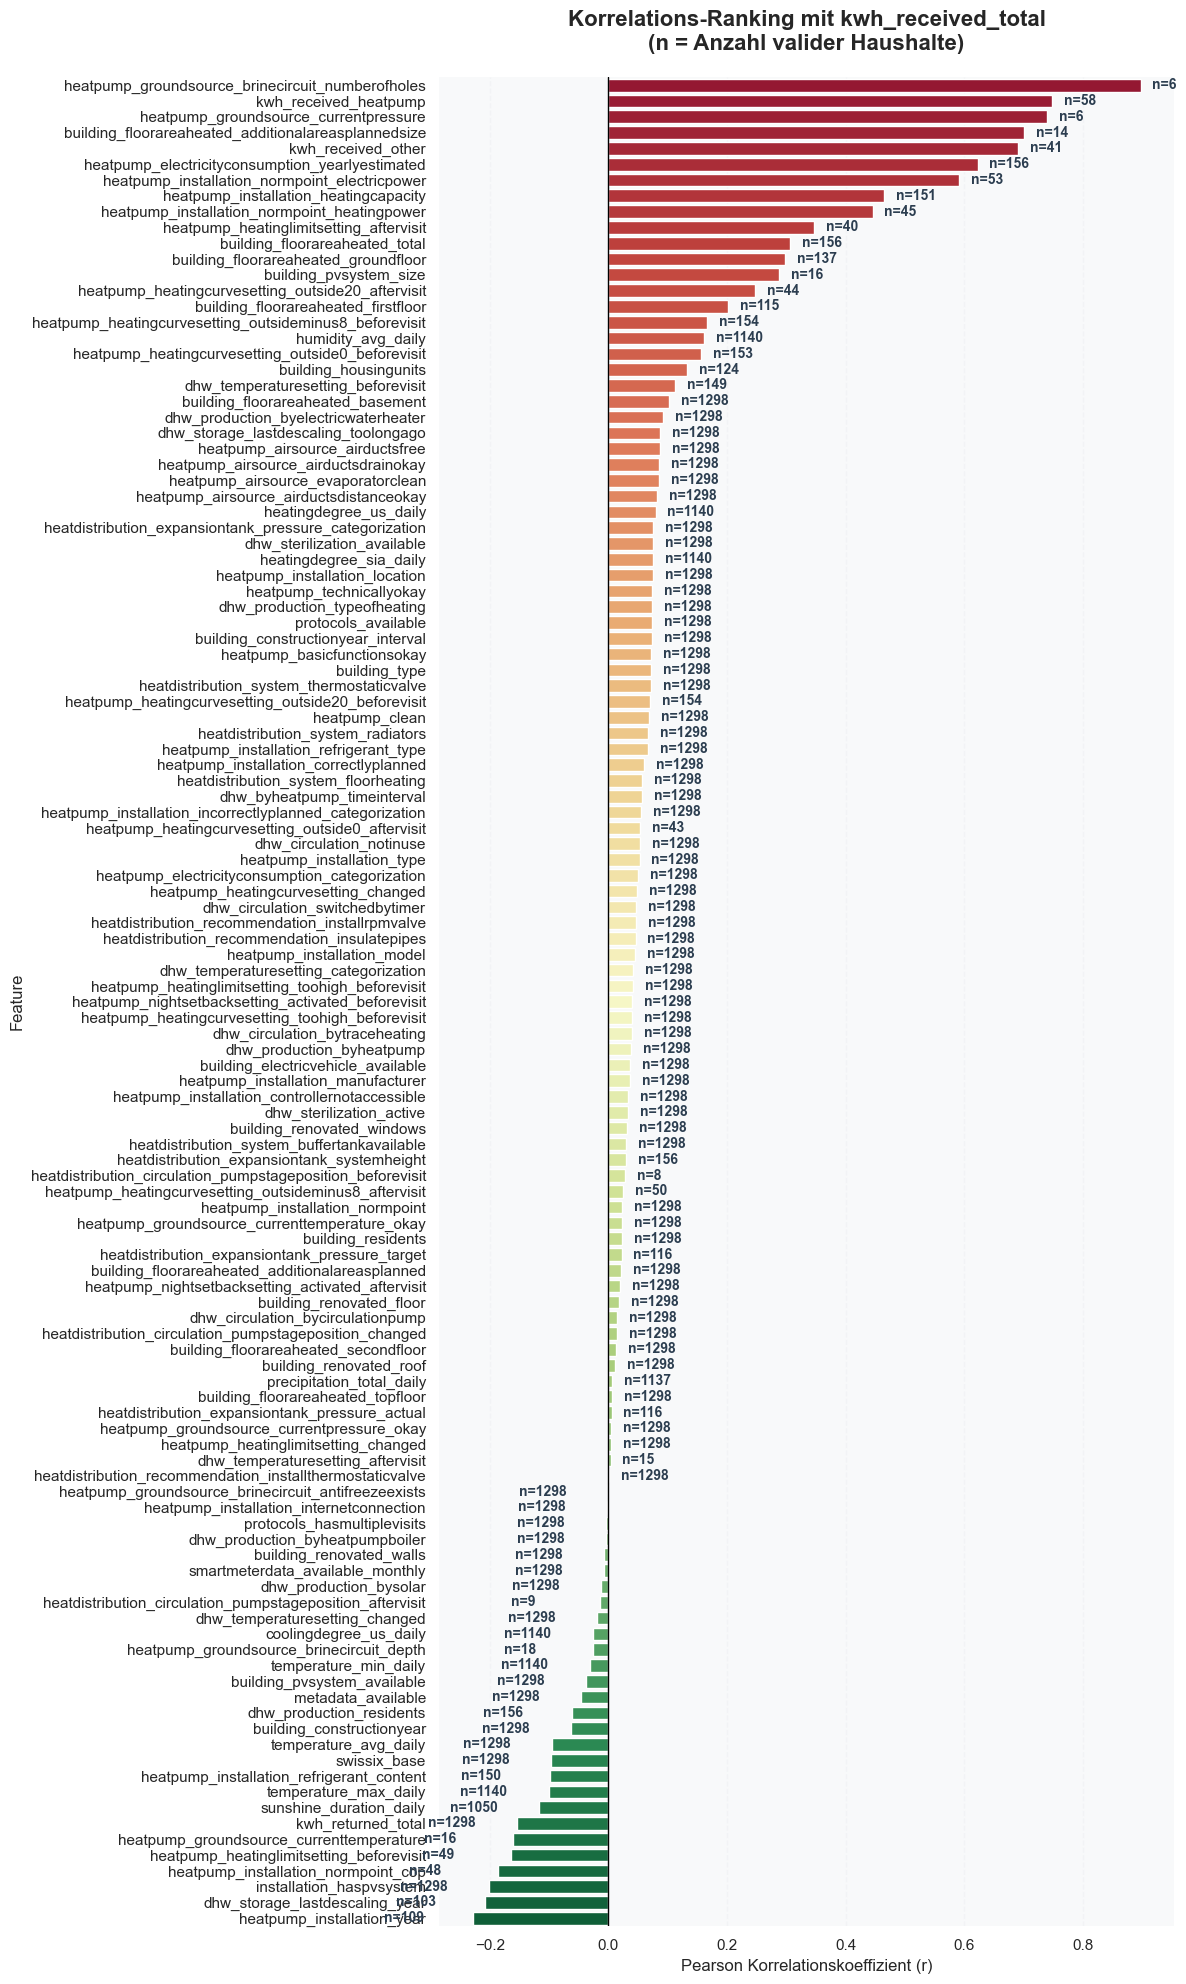

In [10]:
plot_master_correlation_with_counts(df_cleaned)